<a href="https://colab.research.google.com/github/soyeonimu/Codeit_Sprint/blob/main/%5B%EC%8A%A4%ED%94%84%EB%A6%B0%ED%8A%B8%EB%AF%B8%EC%85%98%5D7_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%89%E1%85%A5%E1%86%A8%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8_3%E1%84%90%E1%85%B5%E1%86%B7_%E1%84%80%E1%85%B5%E1%86%B7%E1%84%89%E1%85%A9%E1%84%8B%E1%85%A7%E1%86%AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("husl",8)
sns.set_style("whitegrid")

In [ ]:
df = pd.read_csv('hotel_data_modified.csv')
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,NaN,NaN,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,NaN,NaN,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,NaN,NaN,0,0,0,Check-Out,2015-07-02


In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'required_car_parking_spaces',
       'total_of_special_requests', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

# 1st 결측값 처리

In [ ]:
df.shape # 원본데이터 모양

(119390, 29)

In [ ]:
df.duplicated().sum() # 원본데이터 중복값

33103

In [ ]:
# 결측값제거 진행
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
agent                              16340
company                           112593
days_in_waiting_

In [ ]:
print(df['company'].unique()) # 회사 고유번호 추정
df['agent'].unique() # 에이전트 고유번호 추정

[ nan 110. 113. 270. 178. 240. 154. 144. 307. 268.  59. 204. 312. 318.
  94. 174. 274. 195. 223. 317. 281. 118.  53. 286.  12.  47. 324. 342.
 373. 371. 383.  86.  82. 218.  88.  31. 397. 392. 405. 331. 367.  20.
  83. 416.  51. 395. 102.  34.  84. 360. 394. 457. 382. 461. 478. 386.
 112. 486. 421.   9. 308. 135. 224. 504. 269. 356. 498. 390. 513. 203.
 263. 477. 521. 169. 515. 445. 337. 251. 428. 292. 388. 130. 250. 355.
 254. 543. 531. 528.  62. 120.  42.  81. 116. 530. 103.  39.  16.  92.
  61. 501. 165. 291. 290.  43. 325. 192. 108. 200. 465. 287. 297. 490.
 482. 207. 282. 437. 225. 329. 272.  28.  77. 338.  72. 246. 319. 146.
 159. 380. 323. 511. 407. 278.  80. 403. 399.  14. 137. 343. 346. 347.
 349. 289. 351. 353.  54.  99. 358. 361. 362. 366. 372. 365. 277. 109.
 377. 379.  22. 378. 330. 364. 401. 232. 255. 384. 167. 212. 514. 391.
 400. 376. 402. 396. 302. 398.   6. 370. 369. 409. 168. 104. 408. 413.
 148.  10. 333. 419. 415. 424. 425. 423. 422. 435. 439. 442. 448. 443.
 454. 

array([ nan, 304., 240., 303.,  15., 241.,   8., 250., 115.,   5., 175.,
       134., 156., 243., 242.,   3., 105.,  40., 147., 306., 184.,  96.,
         2., 127.,  95., 146.,   9., 177.,   6., 143., 244., 149., 167.,
       300., 171., 305.,  67., 196., 152., 142., 261., 104.,  36.,  26.,
        29., 258., 110.,  71., 181.,  88., 251., 275.,  69., 248., 208.,
       256., 314., 126., 281., 273., 253., 185., 330., 334., 328., 326.,
       321., 324., 313.,  38., 155.,  68., 335., 308., 332.,  94., 348.,
       310., 339., 375.,  66., 327., 387., 298.,  91., 245., 385., 257.,
       393., 168., 405., 249., 315.,  75., 128., 307.,  11., 436.,   1.,
       201., 183., 223., 368., 336., 291., 464., 411., 481.,  10., 154.,
       468., 410., 390., 440., 495., 492., 493., 434.,  57., 531., 420.,
       483., 526., 472., 429.,  16., 446.,  34.,  78., 139., 252., 270.,
        47., 114., 301., 193., 182., 135., 350., 195., 352., 355., 159.,
       363., 384., 360., 331., 367.,  64., 406., 16

In [ ]:
df = df.drop(columns=['agent', 'company'])
df = df.dropna(axis=0)

In [ ]:
df.shape #company,agent 열 제거, children, country 결측값 492개 행 제거

(118898, 27)

In [ ]:
# 중복값 제거
df.duplicated().sum() # 원본 중복값 : 33103 현재 중복값 :33130

33130

**중복값이 더 증가**하여, 'company`와 `agent` 열이 예약을 구분하는 중요한 데이터일 가능성이 있음

# 2nd 결측값 처리

In [ ]:
# 2nd Try: Original data reload

# 결측값을 제거하지않고 값을 추가하는 방식으로 진행
df = pd.read_csv('hotel_data_modified.csv')
df.shape

(119390, 29)

In [ ]:
# agent와 company의 공란은 0(직접예약)으로 분류 가능여부 확인
print(1 if 0 in df['agent'].unique() else 0)  # 고유번호 0 없음
1 if 0 in df['company'].unique() else 0  # 고유번호 0 없음

0


0

In [ ]:
# agent, company
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

In [ ]:
print(0 if 0 == df['agent'].isna().sum() else 1)
0 if 0 == df['company'].isna().sum() else 1

0


0

In [ ]:
print(df['company'].unique())
df['agent'].unique()

[  0. 110. 113. 270. 178. 240. 154. 144. 307. 268.  59. 204. 312. 318.
  94. 174. 274. 195. 223. 317. 281. 118.  53. 286.  12.  47. 324. 342.
 373. 371. 383.  86.  82. 218.  88.  31. 397. 392. 405. 331. 367.  20.
  83. 416.  51. 395. 102.  34.  84. 360. 394. 457. 382. 461. 478. 386.
 112. 486. 421.   9. 308. 135. 224. 504. 269. 356. 498. 390. 513. 203.
 263. 477. 521. 169. 515. 445. 337. 251. 428. 292. 388. 130. 250. 355.
 254. 543. 531. 528.  62. 120.  42.  81. 116. 530. 103.  39.  16.  92.
  61. 501. 165. 291. 290.  43. 325. 192. 108. 200. 465. 287. 297. 490.
 482. 207. 282. 437. 225. 329. 272.  28.  77. 338.  72. 246. 319. 146.
 159. 380. 323. 511. 407. 278.  80. 403. 399.  14. 137. 343. 346. 347.
 349. 289. 351. 353.  54.  99. 358. 361. 362. 366. 372. 365. 277. 109.
 377. 379.  22. 378. 330. 364. 401. 232. 255. 384. 167. 212. 514. 391.
 400. 376. 402. 396. 302. 398.   6. 370. 369. 409. 168. 104. 408. 413.
 148.  10. 333. 419. 415. 424. 425. 423. 422. 435. 439. 442. 448. 443.
 454. 

array([  0., 304., 240., 303.,  15., 241.,   8., 250., 115.,   5., 175.,
       134., 156., 243., 242.,   3., 105.,  40., 147., 306., 184.,  96.,
         2., 127.,  95., 146.,   9., 177.,   6., 143., 244., 149., 167.,
       300., 171., 305.,  67., 196., 152., 142., 261., 104.,  36.,  26.,
        29., 258., 110.,  71., 181.,  88., 251., 275.,  69., 248., 208.,
       256., 314., 126., 281., 273., 253., 185., 330., 334., 328., 326.,
       321., 324., 313.,  38., 155.,  68., 335., 308., 332.,  94., 348.,
       310., 339., 375.,  66., 327., 387., 298.,  91., 245., 385., 257.,
       393., 168., 405., 249., 315.,  75., 128., 307.,  11., 436.,   1.,
       201., 183., 223., 368., 336., 291., 464., 411., 481.,  10., 154.,
       468., 410., 390., 440., 495., 492., 493., 434.,  57., 531., 420.,
       483., 526., 472., 429.,  16., 446.,  34.,  78., 139., 252., 270.,
        47., 114., 301., 193., 182., 135., 350., 195., 352., 355., 159.,
       363., 384., 360., 331., 367.,  64., 406., 16

In [ ]:
# children
df['children'].unique()

array([ 0.,  1.,  2., 10.,  3., nan])

In [ ]:
df['children'] = df['children'].fillna(0)  # 0명 처리
0 if 0 == df['children'].isna().sum() else 1

0

In [ ]:
# country
df['country'].unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', nan, 'ROU', 'NOR', 'OMN',
       'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA', 'NLD',
       'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN', 'MOZ',
       'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR', 'UKR',
       'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU', 'TUR',
       'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA', 'KOR',
       'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN', 'GEO',
       'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY', 'KWT',
       'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN', 'LBN',
       'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM', 'MKD',
       'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS', 'COM',
       'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI', 'SAU',
       'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU', 'MDG',
       'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI', 'STP',
       'KNA', 'E

In [ ]:
df['country'] = df['country'].fillna('unknown')  # unknown 처리
0 if 0 == df['country'].isna().sum() else 1

0

In [ ]:
df.isna().sum()  # 결측값 처리 완료

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
agent                             0
company                           0
days_in_waiting_list              0
required_car_parking_spaces       0
total_of_special_requests         0
reservation_status          

# 중복값 처리

In [ ]:
df.duplicated().sum()  # 전체 데이터 44224개 중

33103

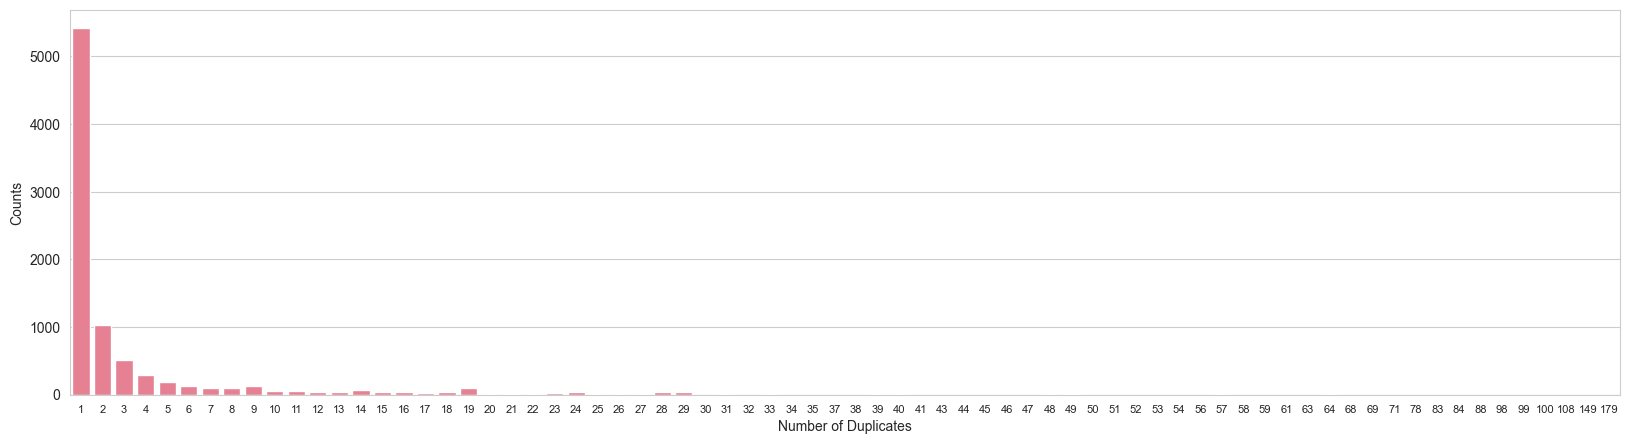

In [ ]:
# 중복된 값 추출 기준 설정
all_duplicates = df[df.duplicated()]

# 모든 열을 기준으로 중복 횟수 계산
dupl_counts = all_duplicates.groupby(list(df.columns)).size()

plt.figure(figsize=(20,5))
sns.countplot(x=dupl_counts.values)
plt.xlabel('Number of Duplicates')
plt.ylabel('Counts')
plt.xticks(fontsize=8)

plt.show()


In [ ]:
dupl_value_counts = dupl_counts.value_counts()
dupl_ratio = dupl_value_counts / (dupl_value_counts.sum()) * 100
dupl_ratio.head(10).sum()

91.93067033976125

10번 이상 중복된 데이터가 전체의 약 9.2%**를 차지한다는 것은 무시하기 어렵다고 판단하여
분석에 활용해보기로 함

# 이상치 처리

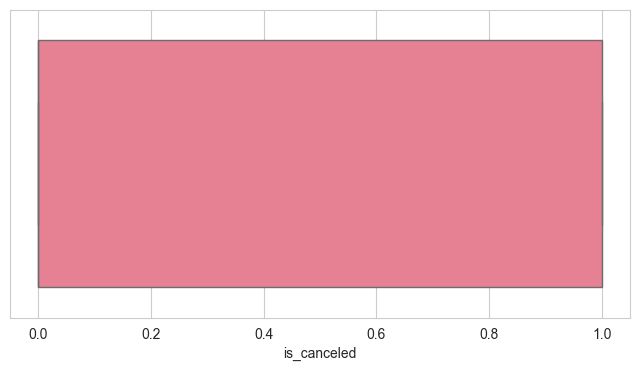

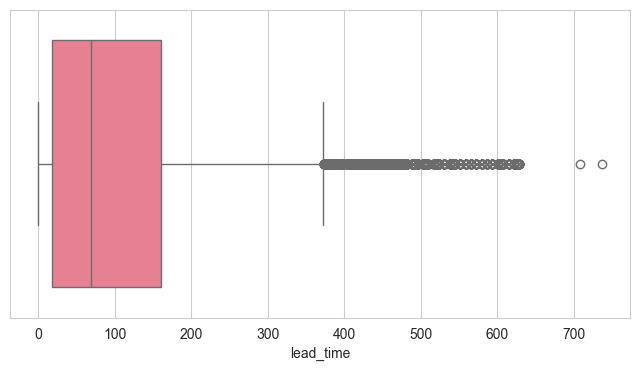

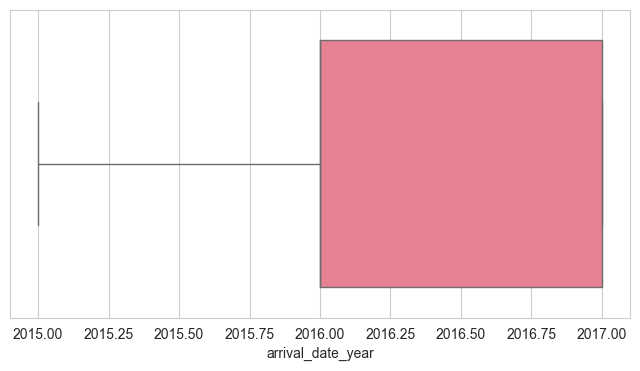

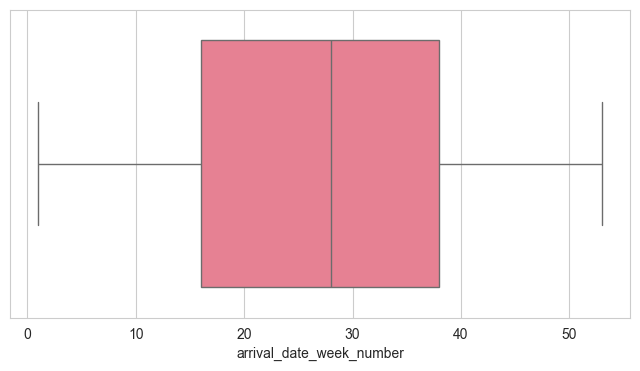

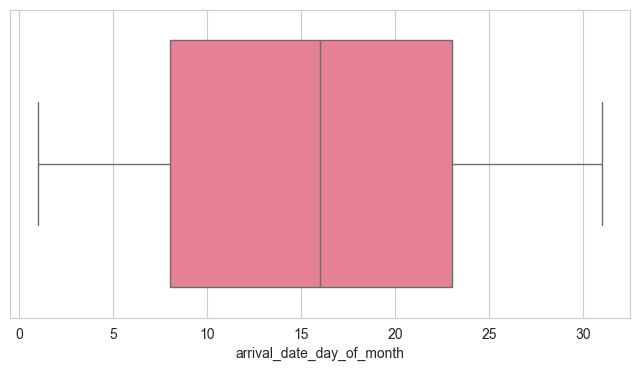

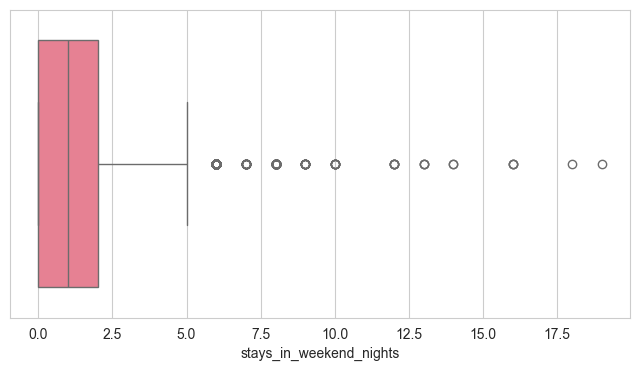

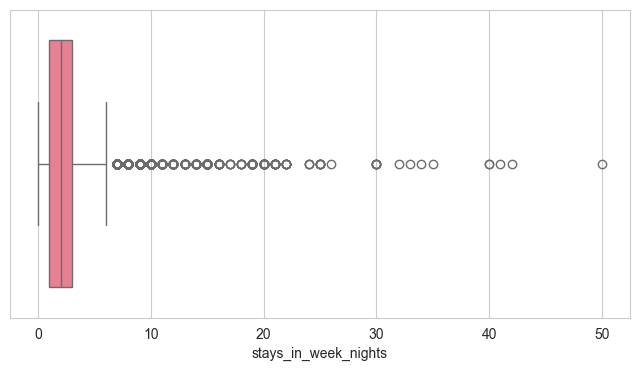

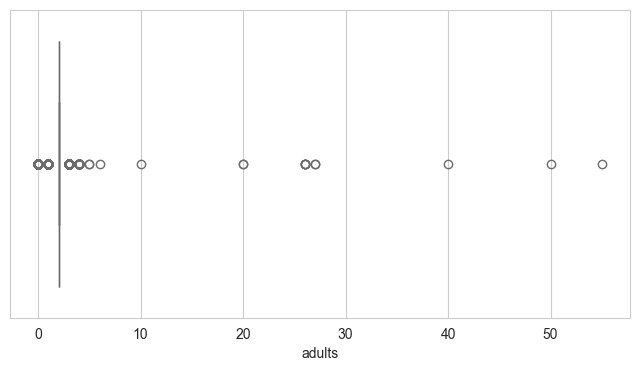

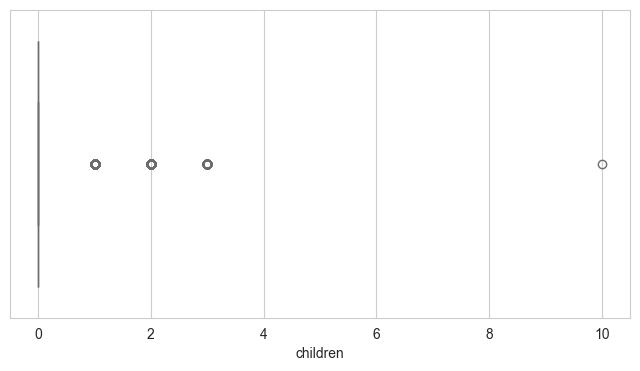

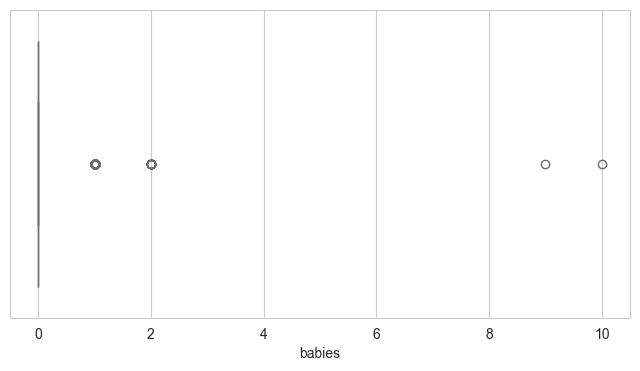

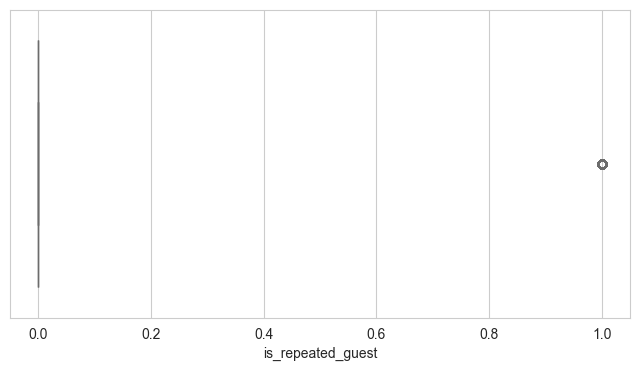

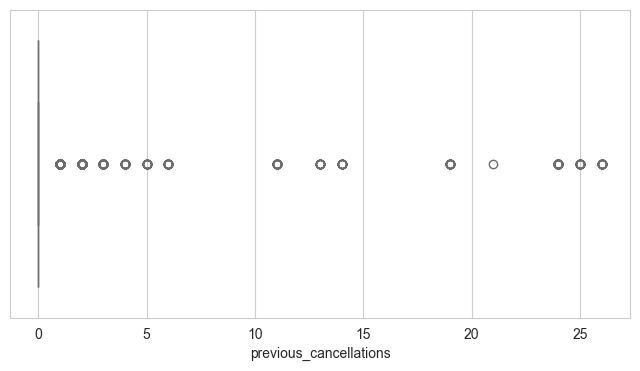

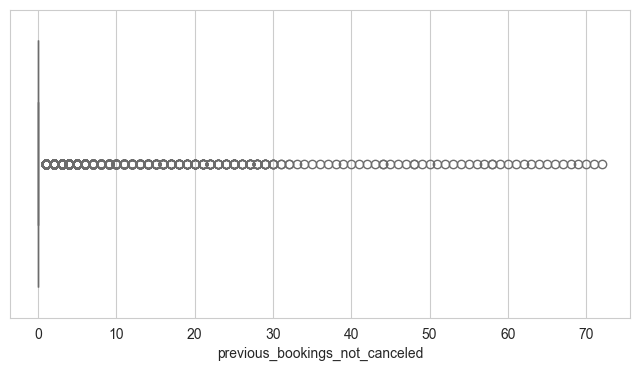

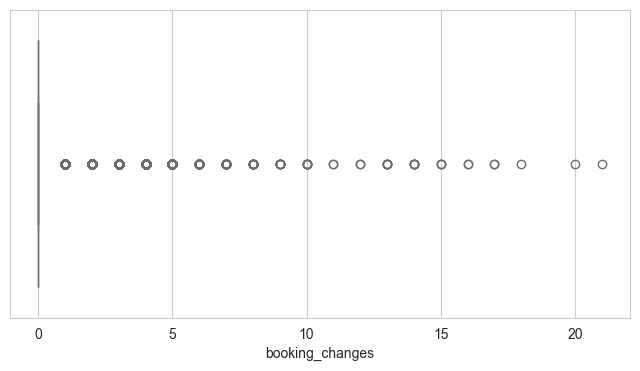

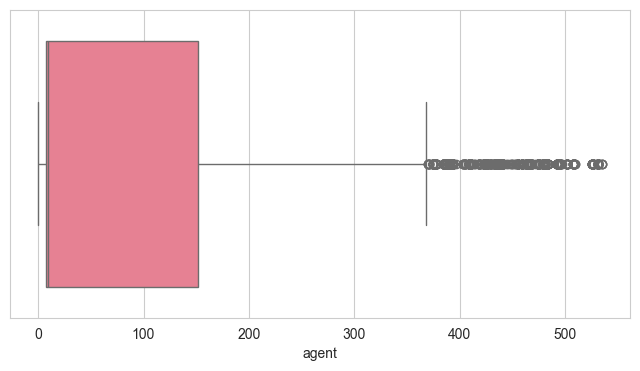

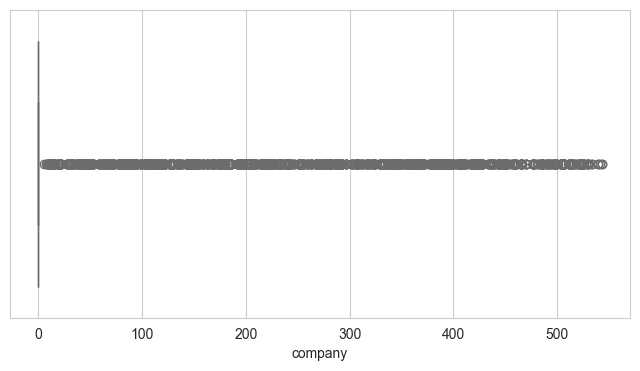

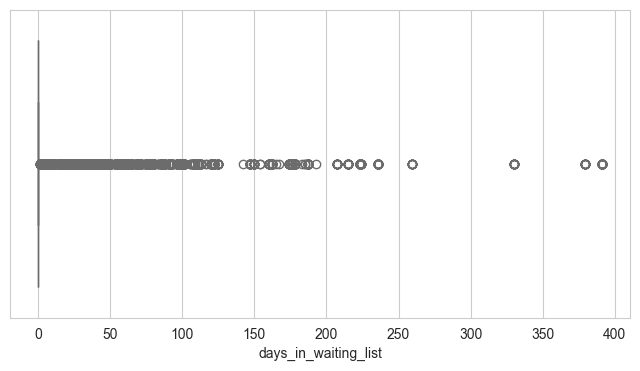

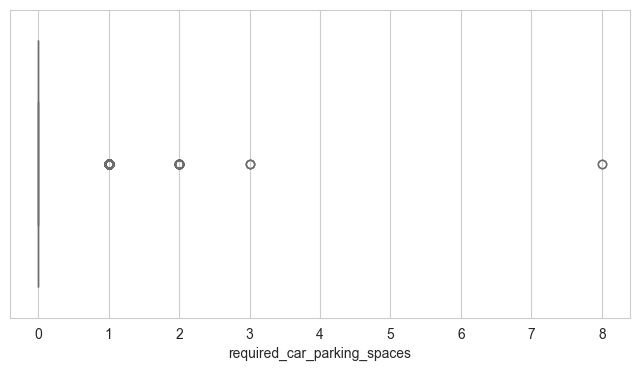

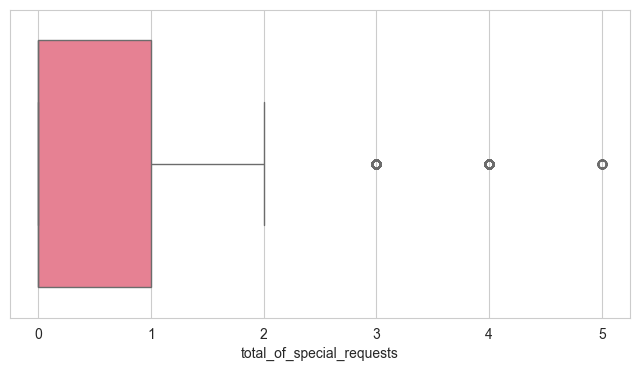

In [ ]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=column)
plt.show()


In [ ]:
# lead_time이 365일 초과하는 데이터
long_lead_time = df[df['lead_time'] > 365]
long_lead_time.shape

(3148, 29)

In [ ]:
# arrival_date_week_number이 53일 초과하는 데이터
abnormal_week_number = df[df['arrival_date_week_number'] > 53]
abnormal_week_number.shape

(0, 29)

In [ ]:
# 비정상 인원 기준으로 필터링
unusual_guests = df[(df['adults'] > 10) & (df['children'] > 5) & (df['babies'] > 5)]
unusual_guests.shape

(0, 29)

그래프를 통해 데이터를 살펴본 결과, 이상치를 그대로 두는 것이 더 적절하다고 판단

- lead_time이 365일 초과:
총 3,148개의 레코드가 있습니다.
이는 전체 데이터 중 상당한 비중을 차지

- arrival_date_week_number이 53 초과:
이상치가 없다

- 비정상 인원 기준으로 필터링 (성인 < 10, 어린이 < 5, 아기 < 5):
이상치가 없다

# 데이터 정비, 가공

In [ ]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
agent                             float64
company                           

In [ ]:
# 카테고리화 하기
categorical_columns = [
    'hotel', 'meal', 'country',
    'market_segment', 'distribution_channel',
    'reserved_room_type', 'assigned_room_type', 'agent', 'company',
    'reservation_status']

df[categorical_columns] = df[categorical_columns].astype('category')

df['children'] = df['children'].astype('int64')



# 'arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month','reservation_status_date' 데이터를 날짜로 변환
df['arrival_date'] = pd.to_datetime(df['arrival_date_year'].astype(str) + '-' +
                                    df['arrival_date_month'] + '-' +
                                    df['arrival_date_day_of_month'].astype(str),
                                    format='%Y-%B-%d')

df['reservation_status_date'] = df['reservation_status_date'].astype('datetime64[ns]')


# 숙박일수 계산
df['Number_of_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# 열 제거
df = df.drop(['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month','stays_in_weekend_nights','stays_in_week_nights'],axis=1)



df.dtypes


hotel                                   category
is_canceled                                int64
lead_time                                  int64
arrival_date_week_number                   int64
adults                                     int64
children                                   int64
babies                                     int64
meal                                    category
country                                 category
market_segment                          category
distribution_channel                    category
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                      category
assigned_room_type                      category
booking_changes                            int64
agent                                   category
company                                 category
days_in_waiting_list                       int64
required_car_parking

# 예약취소율과의 전체적인 상관관계확인

## 1) 전체적인 상관관계

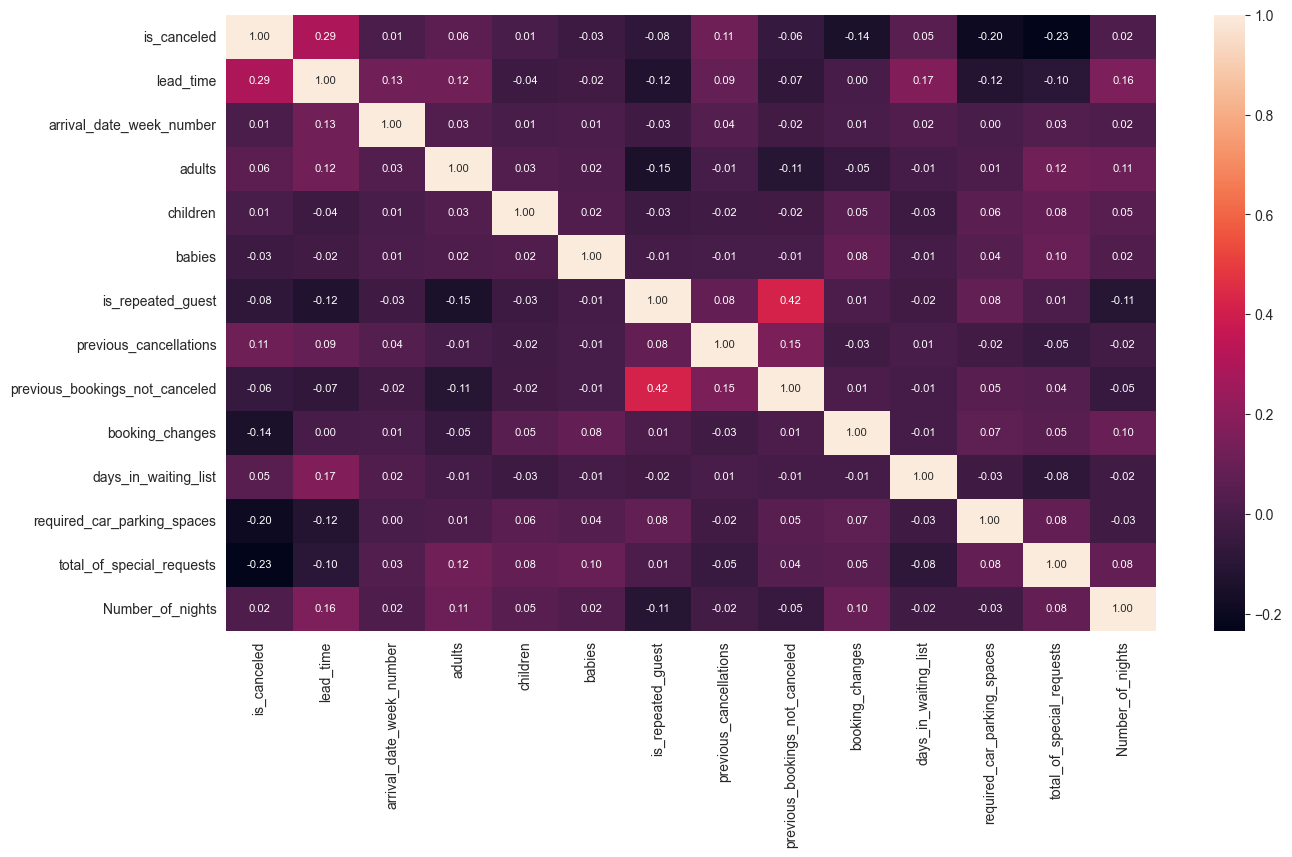

In [ ]:
corr_c = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(15,8))
sns.heatmap(data=corr_c, annot=True, fmt='.2f',annot_kws={"size":8})

plt.show()

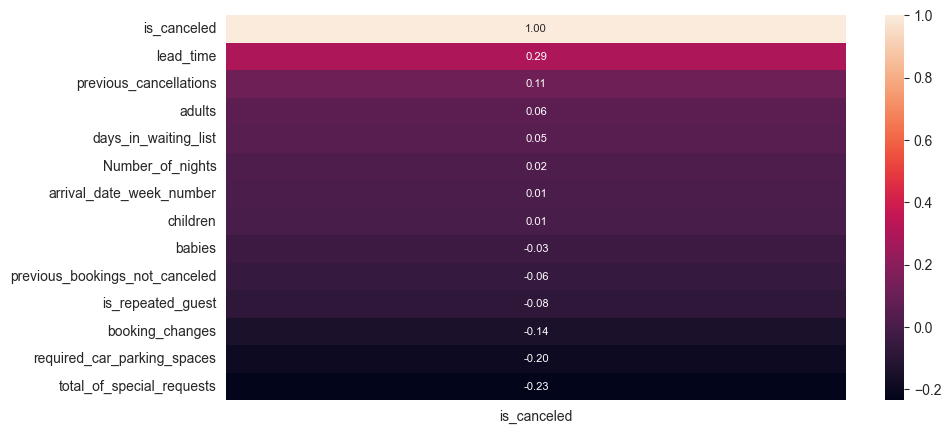

In [ ]:
corr_is_canceled = corr_c[['is_canceled']].sort_values(by='is_canceled', ascending=False)

plt.figure(figsize=(10,5))
sns.heatmap(data=corr_is_canceled, annot=True, fmt='.2f',annot_kws={"size":8})

plt.show()

is canceled 와 lead time이 꽤 높은 상관계수를 보인다.


## 2) 예약상태별 상관관계

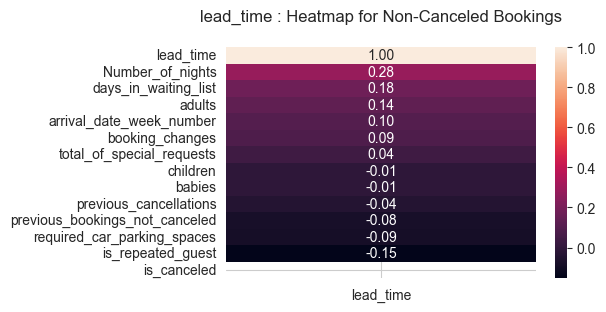

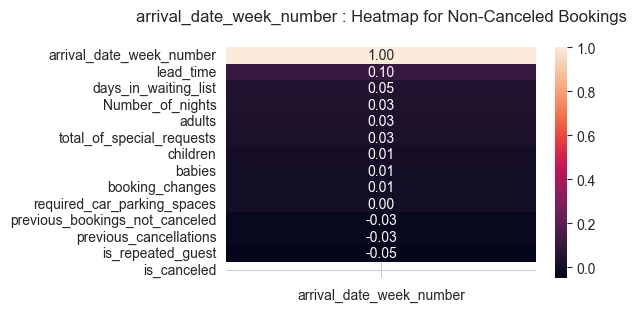

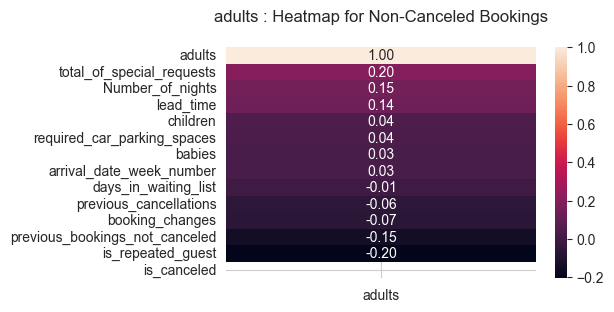

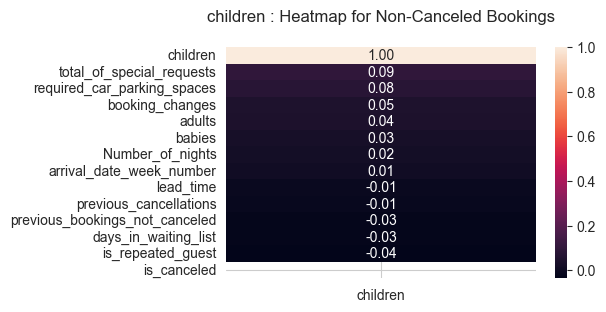

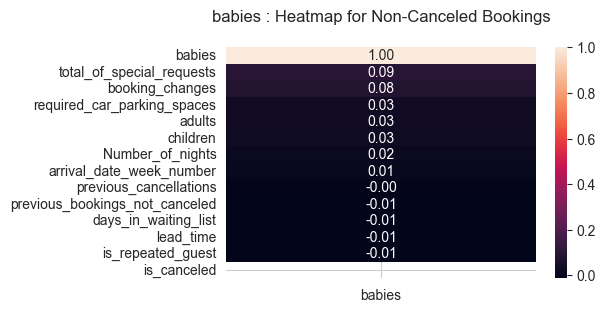

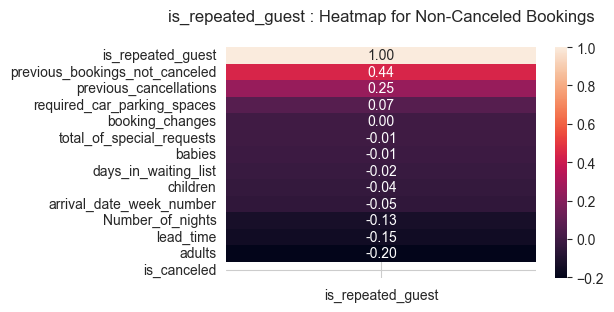

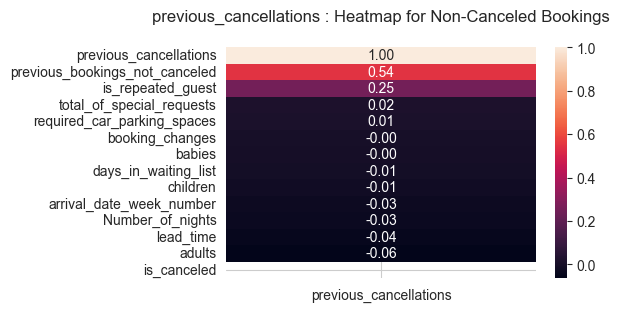

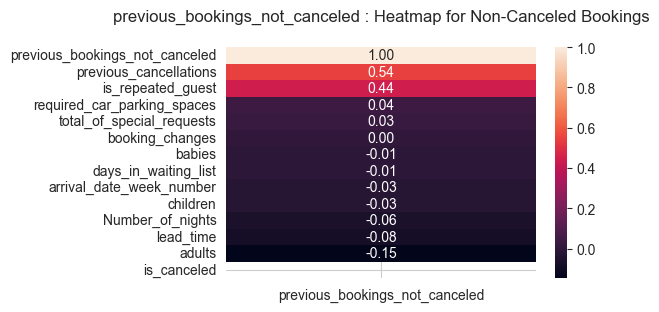

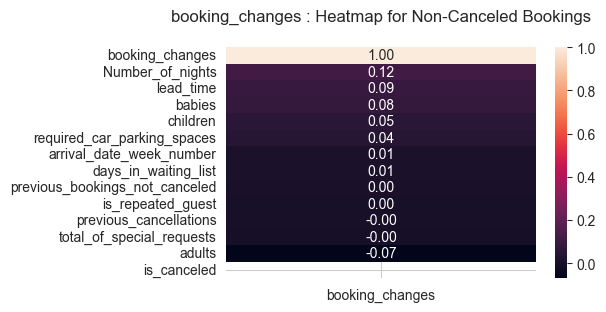

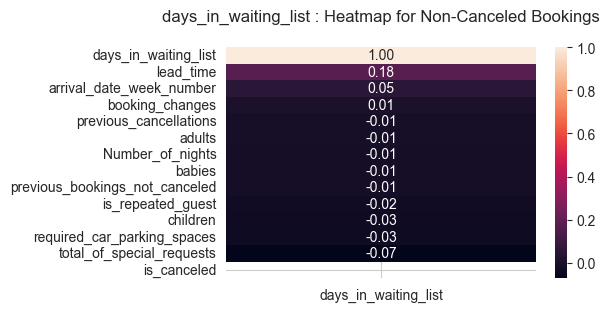

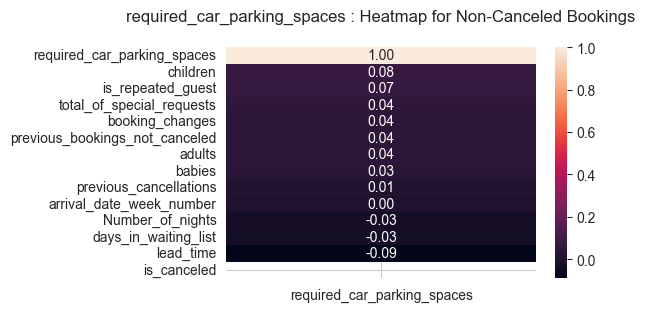

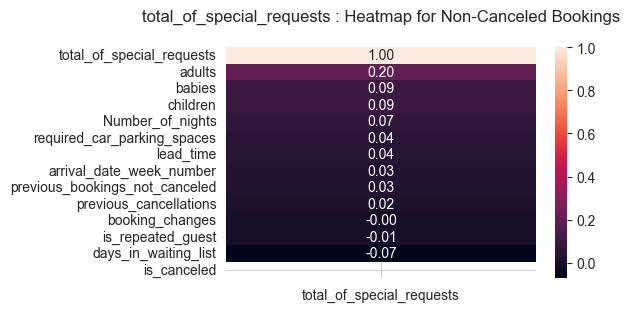

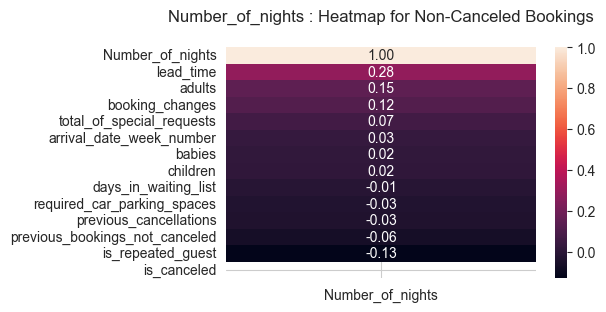

In [ ]:
# 정상예약 필터
canceled_only = df[df['is_canceled'] == 0]

# 숫자 타입만 선택해 상관계수 계산
canceled_only_corr = canceled_only.select_dtypes(include=['float64', 'int64']).corr()

for i in canceled_only_corr.columns[1:]:
    all_plot = canceled_only_corr[[i]].sort_values(by=i,ascending=False)
    plt.figure(figsize=(5,3))
    sns.heatmap(data=all_plot, annot=True, fmt='.2f')
    plt.title(f'{i} : Heatmap for Non-Canceled Bookings\n')

    plt.show()

1등 previous_cancellations와 previous_bookings_not_canceled

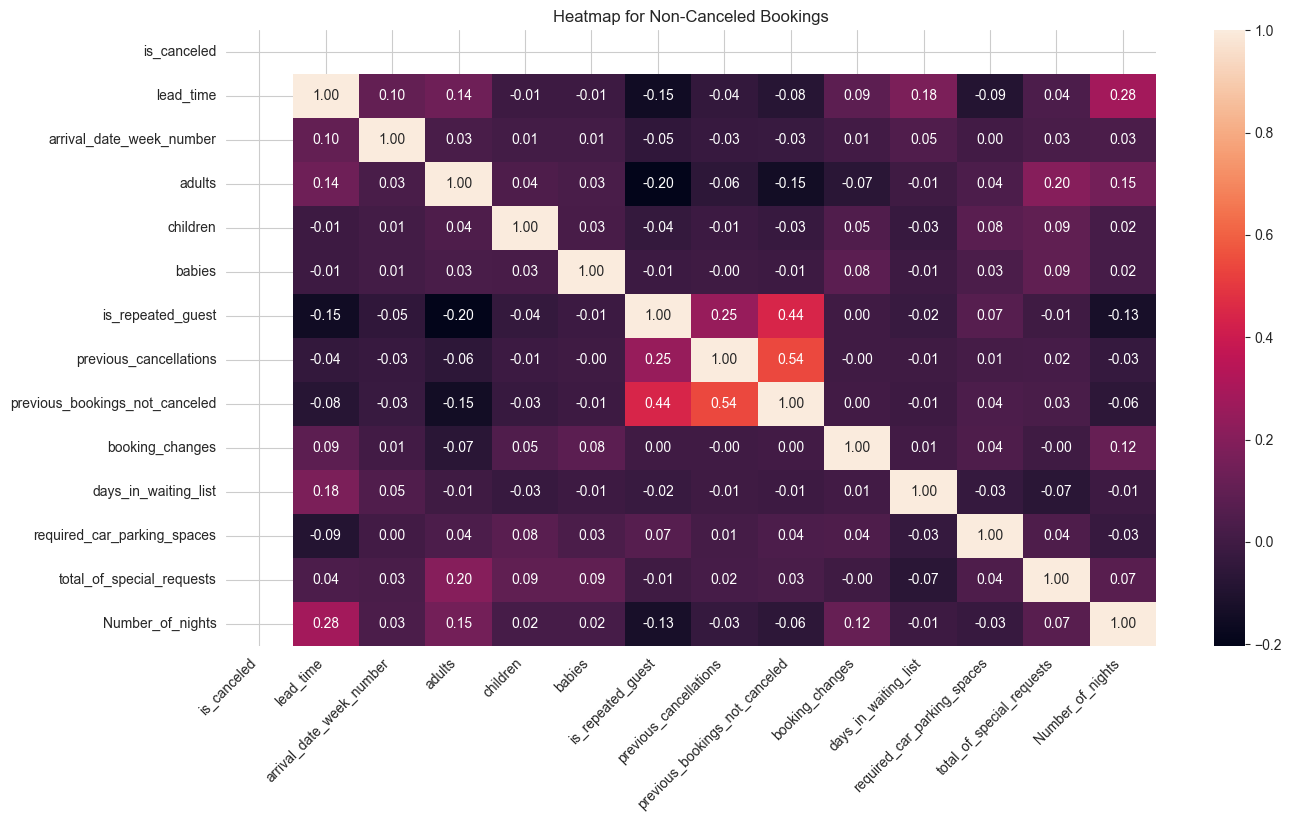

In [ ]:
# 취소예약 필터
canceled_only = df[df['is_canceled'] == 0]

# 숫자 타입만 선택해 상관계수 계산
canceled_only_corr = canceled_only.select_dtypes(include=['float64', 'int64']).corr()


plt.figure(figsize=(15,8))
sns.heatmap(data=canceled_only_corr, annot=True,fmt='.2f')
plt.title('Heatmap for Non-Canceled Bookings')
plt.xticks(rotation=45, ha='right')
plt.show()

# Hotel별 최적화된 취소율 감소 전략

1. 호텔별 기초 통계

In [ ]:
resort_hotel = df[df['hotel'] == 'Resort Hotel' ]
city_hotel = df[df['hotel'] == 'City Hotel' ]

In [ ]:
resort_hotel.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_week_number,adults,children,babies,meal,country,market_segment,...,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,Number_of_nights
count,40060,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060,40060,40060,...,40060.000000,40060.0,40060.0,40060.000000,40060.000000,40060.00000,40060,40060,40060,40060.000000
unique,1,NaN,NaN,NaN,NaN,NaN,NaN,5,126,6,...,NaN,186.0,236.0,NaN,NaN,NaN,3,NaN,NaN,NaN
top,Resort Hotel,NaN,NaN,NaN,NaN,NaN,NaN,BB,PRT,Online TA,...,NaN,240.0,0.0,NaN,NaN,NaN,Check-Out,NaN,NaN,NaN
freq,40060,NaN,NaN,NaN,NaN,NaN,NaN,30005,17630,17729,...,NaN,13905.0,36952.0,NaN,NaN,NaN,28938,NaN,NaN,NaN
mean,NaN,0.277634,92.675686,27.140864,1.867149,0.128682,0.013904,NaN,NaN,NaN,...,0.287968,NaN,NaN,0.527758,0.138068,0.61977,NaN,2016-07-28 14:07:14.947578624,2016-08-15 15:40:38.222665984,4.318547
min,NaN,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.000000,NaN,NaN,0.000000,0.000000,0.00000,NaN,2014-11-18 00:00:00,2015-07-01 00:00:00,0.000000
25%,NaN,0.000000,10.000000,16.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.000000,NaN,NaN,0.000000,0.000000,0.00000,NaN,2016-01-26 00:00:00,2016-02-14 00:00:00,2.000000
50%,NaN,0.000000,57.000000,28.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.000000,NaN,NaN,0.000000,0.000000,0.00000,NaN,2016-07-31 00:00:00,2016-08-19 00:00:00,3.000000
75%,NaN,1.000000,155.000000,38.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.000000,NaN,NaN,0.000000,0.000000,1.00000,NaN,2017-02-11 00:00:00,2017-03-05 00:00:00,7.000000
max,NaN,1.000000,737.000000,53.000000,55.000000,10.000000,2.000000,NaN,NaN,NaN,...,17.000000,NaN,NaN,185.000000,8.000000,5.00000,NaN,2017-09-14 00:00:00,2017-08-31 00:00:00,69.000000


In [ ]:
city_hotel.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_week_number,adults,children,babies,meal,country,market_segment,...,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,Number_of_nights
count,79330,79330.000000,79330.000000,79330.000000,79330.000000,79330.000000,79330.000000,79330,79330,79330,...,79330.000000,79330.0,79330.0,79330.000000,79330.000000,79330.000000,79330,79330,79330,79330.000000
unique,1,NaN,NaN,NaN,NaN,NaN,NaN,4,167,8,...,NaN,224.0,208.0,NaN,NaN,NaN,3,NaN,NaN,NaN
top,City Hotel,NaN,NaN,NaN,NaN,NaN,NaN,BB,PRT,Online TA,...,NaN,9.0,0.0,NaN,NaN,NaN,Check-Out,NaN,NaN,NaN
freq,79330,NaN,NaN,NaN,NaN,NaN,NaN,62305,30960,38748,...,NaN,31955.0,75641.0,NaN,NaN,NaN,46228,NaN,NaN,NaN
mean,NaN,0.417270,109.735724,27.177449,1.850977,0.091365,0.004941,NaN,NaN,NaN,...,0.187369,NaN,NaN,3.226774,0.024367,0.546918,NaN,2016-07-30 17:43:49.048279552,2016-09-04 06:42:49.781924096,2.978142
min,NaN,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,2014-10-17 00:00:00,2015-07-01 00:00:00,0.000000
25%,NaN,0.000000,23.000000,17.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,2016-02-05 00:00:00,2016-03-25 00:00:00,2.000000
50%,NaN,0.000000,74.000000,27.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,2016-08-10 00:00:00,2016-09-14 00:00:00,3.000000
75%,NaN,1.000000,163.000000,38.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.000000,NaN,NaN,0.000000,0.000000,1.000000,NaN,2017-02-06 00:00:00,2017-03-24 00:00:00,4.000000
max,NaN,1.000000,629.000000,53.000000,4.000000,3.000000,10.000000,NaN,NaN,NaN,...,21.000000,NaN,NaN,391.000000,3.000000,5.000000,NaN,2017-09-07 00:00:00,2017-08-31 00:00:00,57.000000


# 호텔별 취소 상관계수

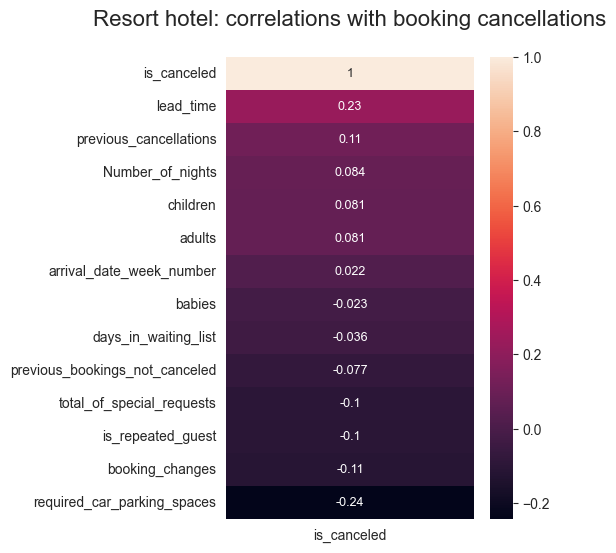

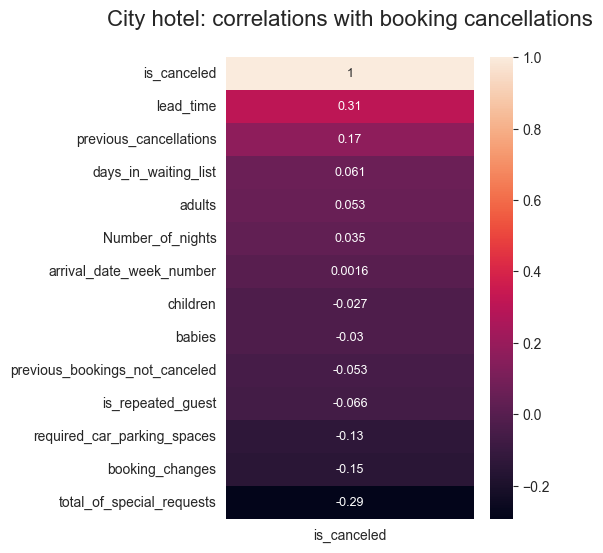

In [ ]:
resort_hotel_corr = resort_hotel.select_dtypes(include=['int64','float64']).corr()
city_hotel_corr = city_hotel.select_dtypes(include=['int64','float64']).corr()

resort_hotel_corr_sort = resort_hotel_corr[['is_canceled']].sort_values(by='is_canceled',ascending=False)

plt.figure(figsize=(4,6))
sns.heatmap(data=resort_hotel_corr_sort,annot=True,annot_kws={'size':9})
plt.title('Resort hotel: correlations with booking cancellations\n',fontsize=16)

plt.show()

city_hotel_corr_sort = city_hotel_corr[['is_canceled']].sort_values(by='is_canceled',ascending=False)

plt.figure(figsize=(4,6))
sns.heatmap(data=city_hotel_corr_sort,annot=True,annot_kws={'size':9})
plt.title('City hotel: correlations with booking cancellations\n',fontsize=16)

plt.show()

# 정상예약일때

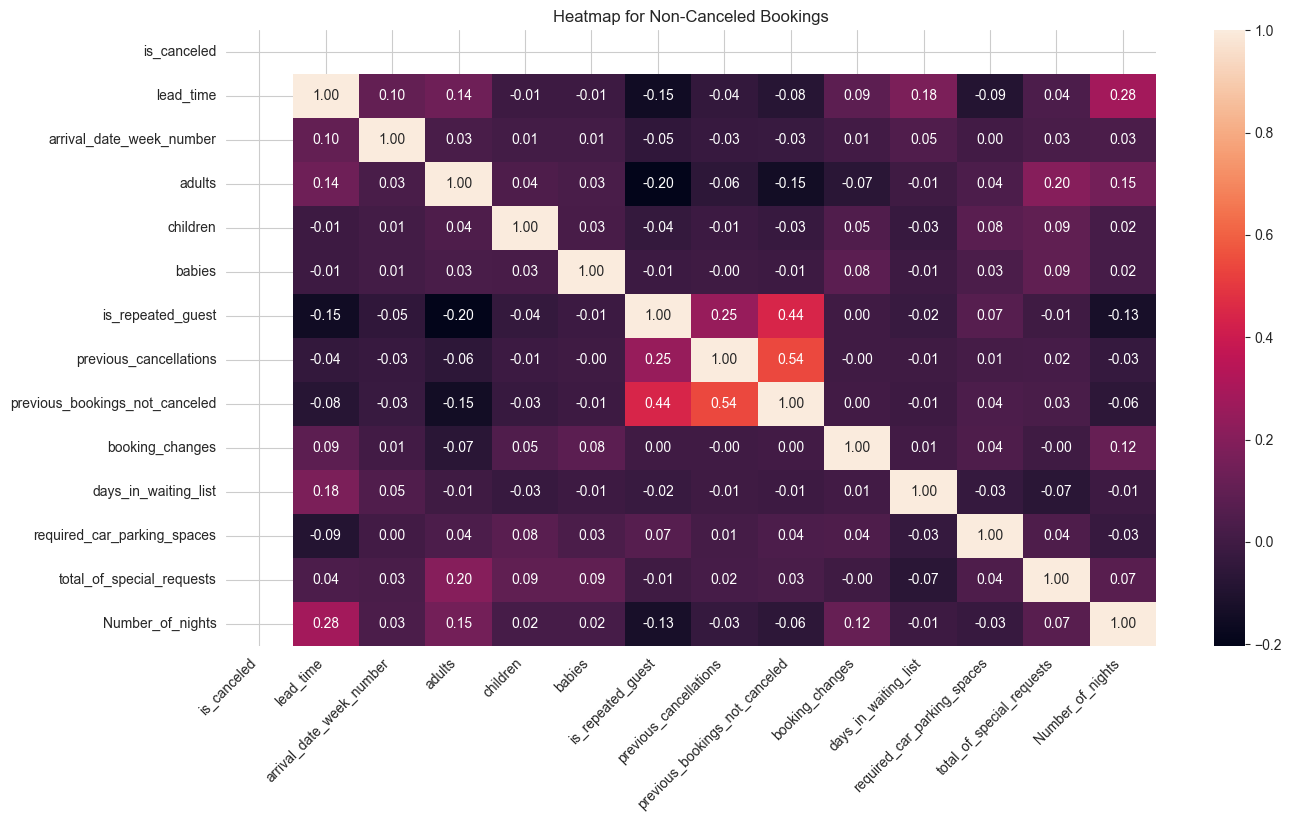

In [ ]:
# 취소예약 필터
canceled_only = df[df['is_canceled'] == 0]

# 숫자 타입만 선택해 상관계수 계산
canceled_only_corr = canceled_only.select_dtypes(include=['float64', 'int64']).corr()


plt.figure(figsize=(15,8))
sns.heatmap(data=canceled_only_corr, annot=True,fmt='.2f')
plt.title('Heatmap for Non-Canceled Bookings')
plt.xticks(rotation=45, ha='right')
plt.show()

- Resort Hotel corr rank:

(+)
1. lead time
2. previous cancellations
3. children
4. adults
5. stays in weekend night

    **증가시, cancellation 증가**

(-)
1. required parking spaces
2. booking changes
3. repeated guest
4. special requests
5. previous bookings not canceled

    **증가시, cancellation 감소**


- City Hotel corr rank :

(+)
1. lead time
2. previous cancellations
3. days in waiting list
4. adults
5. staying in week nights

    **증가시, cancellation 증가**

(-)
1. special requests
2. booking changes
3. required parking spaces
4. repeated guest
5. previous bookings not canceled

    **증가시, cancellation 감소**

In [ ]:
df.to_csv('hotel_data.csv', index=False)

# 회귀계수 분석

In [ ]:
import statsmodels.api as sm

# 주요 변수 선택
selected_columns = ['lead_time', 'previous_cancellations', 'Number_of_nights', 'total_of_special_requests',
                    'is_repeated_guest','booking_changes','days_in_waiting_list','required_car_parking_spaces']
X = df[selected_columns]
y = df['is_canceled']

# 상수항 추가
X = sm.add_constant(X)

# 로지스틱 회귀 분석
model = sm.Logit(y, X)
result = model.fit()

# 결과 출력
print(result.summary())


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Optimization terminated successfully.
         Current function value: 0.539099
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:               119390
Model:                          Logit   Df Residuals:                   119381
Method:                           MLE   Df Model:                            8
Date:                Mon, 18 Nov 2024   Pseudo R-squ.:                  0.1822
Time:                        19:45:42   Log-Likelihood:                -64363.
converged:                       True   LL-Null:                       -78699.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.6005      0.013    -44.691      0.000  

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


In [ ]:
# Resort Hotel과 City Hotel로 데이터 분리
resort_data = df[df['hotel'] == 'Resort Hotel']
city_data = df[df['hotel'] == 'City Hotel']

# 주요 변수 선택
selected_columns = ['lead_time', 'previous_cancellations', 'Number_of_nights', 'total_of_special_requests',
                    'is_repeated_guest', 'booking_changes', 'days_in_waiting_list']

# 리조트 호텔
X_resort = resort_data[selected_columns]
y_resort = resort_data['is_canceled']
X_resort = sm.add_constant(X_resort)

# 시티 호텔
X_city = city_data[selected_columns]
y_city = city_data['is_canceled']
X_city = sm.add_constant(X_city)

# 로지스틱 회귀 분석
model_resort = sm.Logit(y_resort, X_resort).fit()
model_city = sm.Logit(y_city, X_city).fit()

# 결과 출력
print("Resort Hotel Logistic Regression Results")
print(model_resort.summary())
print("\nCity Hotel Logistic Regression Results")
print(model_city.summary())

Optimization terminated successfully.
         Current function value: 0.527618
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.560892
         Iterations 7
Resort Hotel Logistic Regression Results
                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:                40060
Model:                          Logit   Df Residuals:                    40052
Method:                           MLE   Df Model:                            7
Date:                Mon, 18 Nov 2024   Pseudo R-squ.:                  0.1068
Time:                        19:54:25   Log-Likelihood:                -21136.
converged:                       True   LL-Null:                       -23664.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------